# CREDIT CARD FRAUD DETECTION

In [1]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score
)
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine import SMOTETomek
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("✓Libraries imported")

✓Libraries imported


## 1. Load and Explore the Data

In [2]:
FILE_PATH = r"C:\Users\mht23\OneDrive\Desktop\CodSoft Internship\T2 - Credit Card Fraud Detection\creditcard.csv"

# Auto-detect file type and load
if FILE_PATH.endswith('.xlsx') or FILE_PATH.endswith('.xls'):
    df = pd.read_excel(FILE_PATH)
    print("✓ Loaded Excel file")
else:
    df = pd.read_csv(FILE_PATH)
    print("✓ Loaded CSV file")

print(f"\nDataset Shape: {df.shape[0]:,} transactions, {df.shape[1]} features")
print(f"Memory Usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

✓ Loaded CSV file

Dataset Shape: 284,807 transactions, 31 features
Memory Usage: 67.36 MB


In [3]:
# Any rows where all features are NaN (Excel padding)
df = df.dropna(how='all')

print(f"Before cleaning: {len(df):,} transactions")
df = df.dropna()
print(f"After cleaning: {len(df):,} transactions")
print(f"Rows removed: {df.shape[0] - len(df):,}")

Before cleaning: 284,807 transactions
After cleaning: 284,807 transactions
Rows removed: 0


In [4]:
df.head(10)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
5,2.0,-0.425966,0.960523,1.141109,-0.168252,0.420987,-0.029728,0.476201,0.260314,-0.568671,-0.371407,1.341262,0.359894,-0.358091,-0.137134,0.517617,0.401726,-0.058133,0.068653,-0.033194,0.084968,-0.208254,-0.559825,-0.026398,-0.371427,-0.232794,0.105915,0.253844,0.081080,3.67,0
6,4.0,1.229658,0.141004,0.045371,1.202613,0.191881,0.272708,-0.005159,0.081213,0.464960,-0.099254,-1.416907,-0.153826,-0.751063,0.167372,0.050144,-0.443587,0.002821,-0.611987,-0.045575,-0.219633,-0.167716,-0.270710,-0.154104,-0.780055,0.750137,-0.257237,0.034507,0.005168,4.99,0
7,7.0,-0.644269,1.417964,1.074380,-0.492199,0.948934,0.428118,1.120631,-3.807864,0.615375,1.249376,-0.619468,0.291474,1.757964,-1.323865,0.686133,-0.076127,-1.222127,-0.358222,0.324505,-0.156742,1.943465,-1.015455,0.057504,-0.649709,-0.415267,-0.051634,-1.206921,-1.085339,40.80,0
8,7.0,-0.894286,0.286157,-0.113192,-0.271526,2.669599,3.721818,0.370145,0.851084,-0.392048,-0.410430,-0.705117,-0.110452,-0.286254,0.074355,-0.328783,-0.210077,-0.499768,0.118765,0.570328,0.052736,-0.073425,-0.268092,-0.204233,1.011592,0.373205,-0.384157,0.011747,0.142404,93.20,0
9,9.0,-0.338262,1.119593,1.044367,-0.222187,0.499361,-0.246761,0.651583,0.069539,-0.736727,-0.366846,1.017614,0.836390,1.006844,-0.443523,0.150219,0.739453,-0.540980,0.476677,0.451773,0.203711,-0.246914,-0.633753,-0.120794,-0.385050,-0.069733,0.094199,0.246219,0.083076,3.68,0


In [5]:
print("Dataset Information:")
print(df.info())

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  fl

In [6]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,2.238554e-15,1.724421e-15,-1.245415e-15,8.238900e-16,1.213481e-15,4.866699e-15,1.436219e-15,-3.768179e-16,9.707851e-16,1.036249e-15,6.418678e-16,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,1.088850e+00,1.020713e+00,9.992014e-01,9.952742e-01,9.585956e-01,9.153160e-01,8.762529e-01,8.493371e-01,8.381762e-01,8.140405e-01,7.709250e-01,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,-2.458826e+01,-4.797473e+00,-1.868371e+01,-5.791881e+00,-1.921433e+01,-4.498945e+00,-1.412985e+01,-2.516280e+01,-9.498746e+00,-7.213527e+00,-5.449772e+01,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,-5.354257e-01,-7.624942e-01,-4.055715e-01,-6.485393e-01,-4.255740e-01,-5.828843e-01,-4.680368e-01,-4.837483e-01,-4.988498e-01,-4.562989e-01,-2.117214e-01,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,-9.291738e-02,-3.275735e-02,1.400326e-01,-1.356806e-02,5.060132e-02,4.807155e-02,6.641332e-02,-6.567575e-02,-3.636312e-03,3.734823e-03,-6.248109e-02,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,4.539234e-01,7.395934e-01,6.182380e-01,6.625050e-01,4.931498e-01,6.488208e-01,5.232963e-01,3.996750e-01,5.008067e-01,4.589494e-01,1.330408e-01,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,2.374514e+01,1.201891e+01,7.848392e+00,7.126883e+00,1.052677e+01,8.877742e+00,1.731511e+01,9.253526e+00,5.041069e+00,5.591971e+00,3.942090e+01,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [7]:
# Check for missing values
missing = df.isnull().sum()
if missing.sum() > 0:
    print("Missing values found:")
    print(missing[missing > 0])
else:
    print("✓ No missing values")

✓ No missing values


In [8]:
# Class distribution
class_counts = df['Class'].value_counts()
class_pct = df['Class'].value_counts(normalize=True) * 100

print("CLASS DISTRIBUTION (Imbalance Analysis)")
print("="*60)
print(f"\nLegitimate Transactions (Class 0): {class_counts[0]:,} ({class_pct[0]:.4f}%)")
print(f"Fraudulent Transactions (Class 1): {class_counts[1]:,} ({class_pct[1]:.4f}%)")
print(f"\nImbalance Ratio: {class_counts[0]/class_counts[1]:.1f}:1")
print(f"\nHIGHLY IMBALANCED dataset")

CLASS DISTRIBUTION (Imbalance Analysis)

Legitimate Transactions (Class 0): 284,315 (99.8273%)
Fraudulent Transactions (Class 1): 492 (0.1727%)

Imbalance Ratio: 577.9:1

HIGHLY IMBALANCED dataset


## 2. Exploratory Data Analysis (EDA)

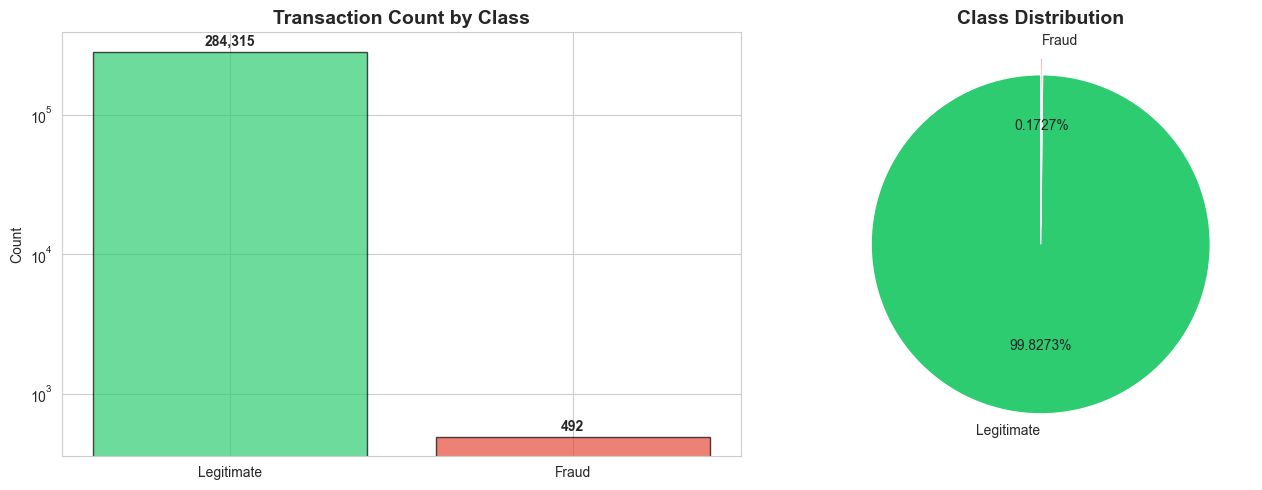

In [9]:
# Visualize class imbalance
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
colors = ['#2ecc71', '#e74c3c']
axes[0].bar(['Legitimate', 'Fraud'], class_counts, color=colors, alpha=0.7, edgecolor='black')
axes[0].set_ylabel('Count')
axes[0].set_title('Transaction Count by Class', fontsize=14, fontweight='bold')
axes[0].set_yscale('log')  # Log scale to see fraud clearly
for i, v in enumerate(class_counts):
    axes[0].text(i, v * 1.1, f'{v:,}', ha='center', fontweight='bold')

# Pie chart
axes[1].pie(class_counts, labels=['Legitimate', 'Fraud'], autopct='%1.4f%%', 
            colors=colors, startangle=90, explode=[0, 0.1])
axes[1].set_title('Class Distribution', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

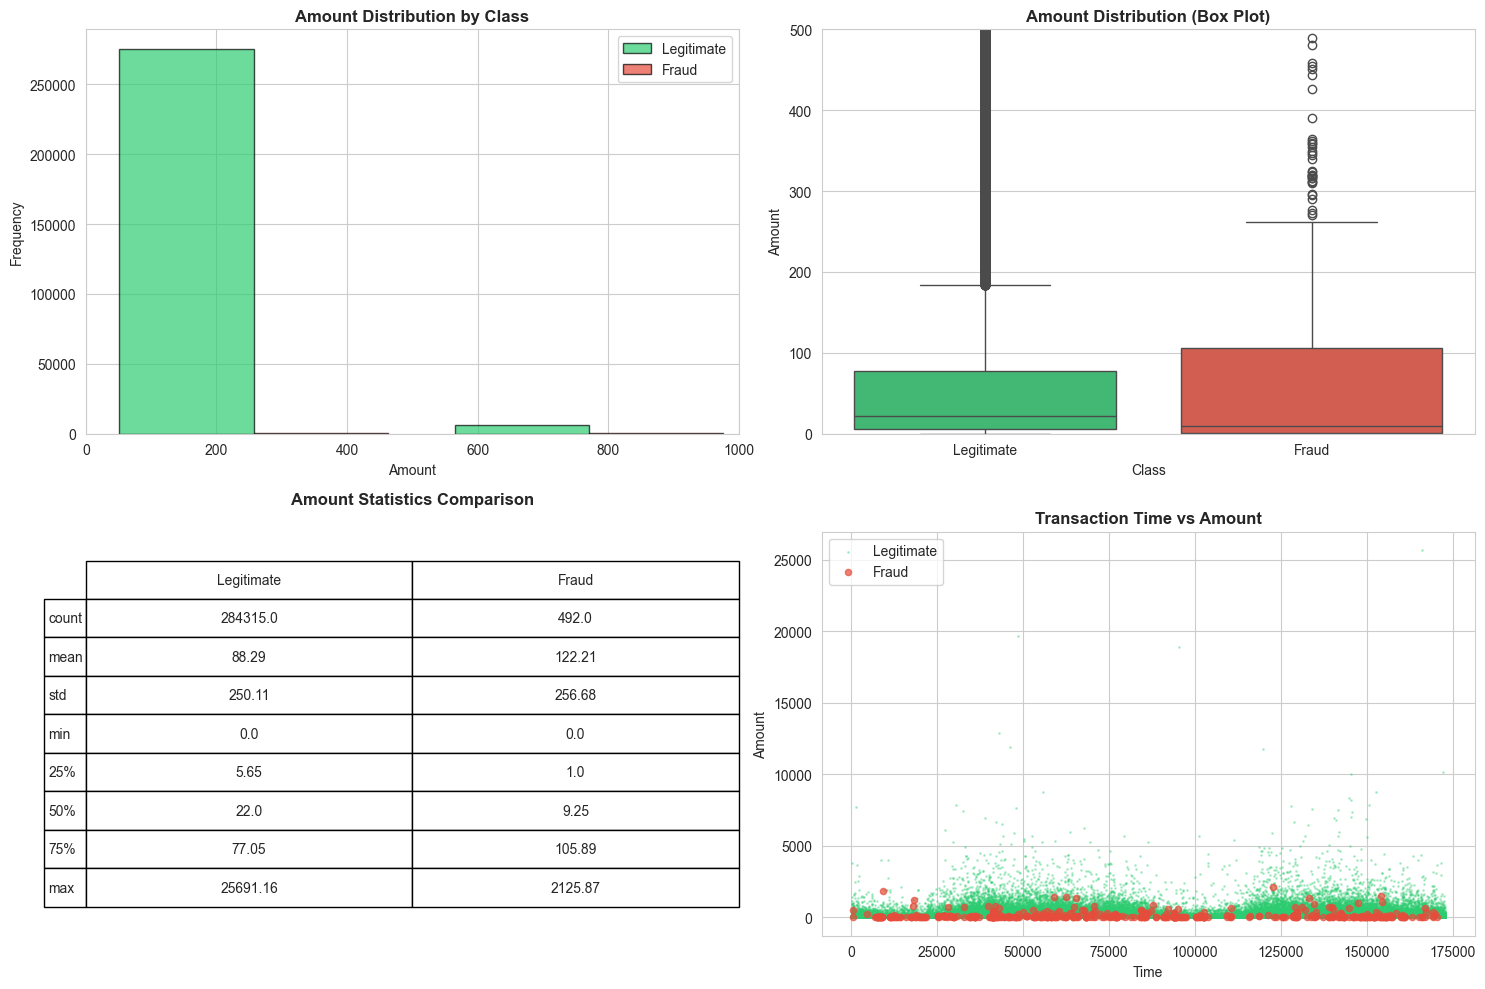


 Observations:
Average Legitimate Transaction: $88.29
Average Fraudulent Transaction: $122.21
Max Fraudulent Amount: $2125.87


In [10]:
# Transaction amount analysis
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Amount distribution by class
axes[0, 0].hist([df[df['Class']==0]['Amount'], df[df['Class']==1]['Amount']],
                bins=50, label=['Legitimate', 'Fraud'], color=colors, alpha=0.7, edgecolor='black')
axes[0, 0].set_xlabel('Amount')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Amount Distribution by Class', fontweight='bold')
axes[0, 0].legend()
axes[0, 0].set_xlim(0, 1000)  # Zoom in to see pattern

# Box plot
df_plot = df[['Amount', 'Class']].copy()
df_plot['Class'] = df_plot['Class'].map({0: 'Legitimate', 1: 'Fraud'})
sns.boxplot(data=df_plot, x='Class', y='Amount', ax=axes[0, 1], palette=colors)
axes[0, 1].set_title('Amount Distribution (Box Plot)', fontweight='bold')
axes[0, 1].set_ylim(0, 500)

# Statistical comparison
fraud_stats = df[df['Class']==1]['Amount'].describe()
legit_stats = df[df['Class']==0]['Amount'].describe()
stats_comparison = pd.DataFrame({
    'Legitimate': legit_stats,
    'Fraud': fraud_stats
})
axes[1, 0].axis('off')
table = axes[1, 0].table(cellText=stats_comparison.round(2).values,
                         rowLabels=stats_comparison.index,
                         colLabels=stats_comparison.columns,
                         cellLoc='center', loc='center')
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2)
axes[1, 0].set_title('Amount Statistics Comparison', fontweight='bold', pad=20)

# Time distribution
axes[1, 1].scatter(df[df['Class']==0]['Time'], df[df['Class']==0]['Amount'], 
                   alpha=0.3, s=1, label='Legitimate', color=colors[0])
axes[1, 1].scatter(df[df['Class']==1]['Time'], df[df['Class']==1]['Amount'], 
                   alpha=0.7, s=20, label='Fraud', color=colors[1])
axes[1, 1].set_xlabel('Time')
axes[1, 1].set_ylabel('Amount')
axes[1, 1].set_title('Transaction Time vs Amount', fontweight='bold')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

print("\n Observations:")
print(f"Average Legitimate Transaction: ${legit_stats['mean']:.2f}")
print(f"Average Fraudulent Transaction: ${fraud_stats['mean']:.2f}")
print(f"Max Fraudulent Amount: ${fraud_stats['max']:.2f}")

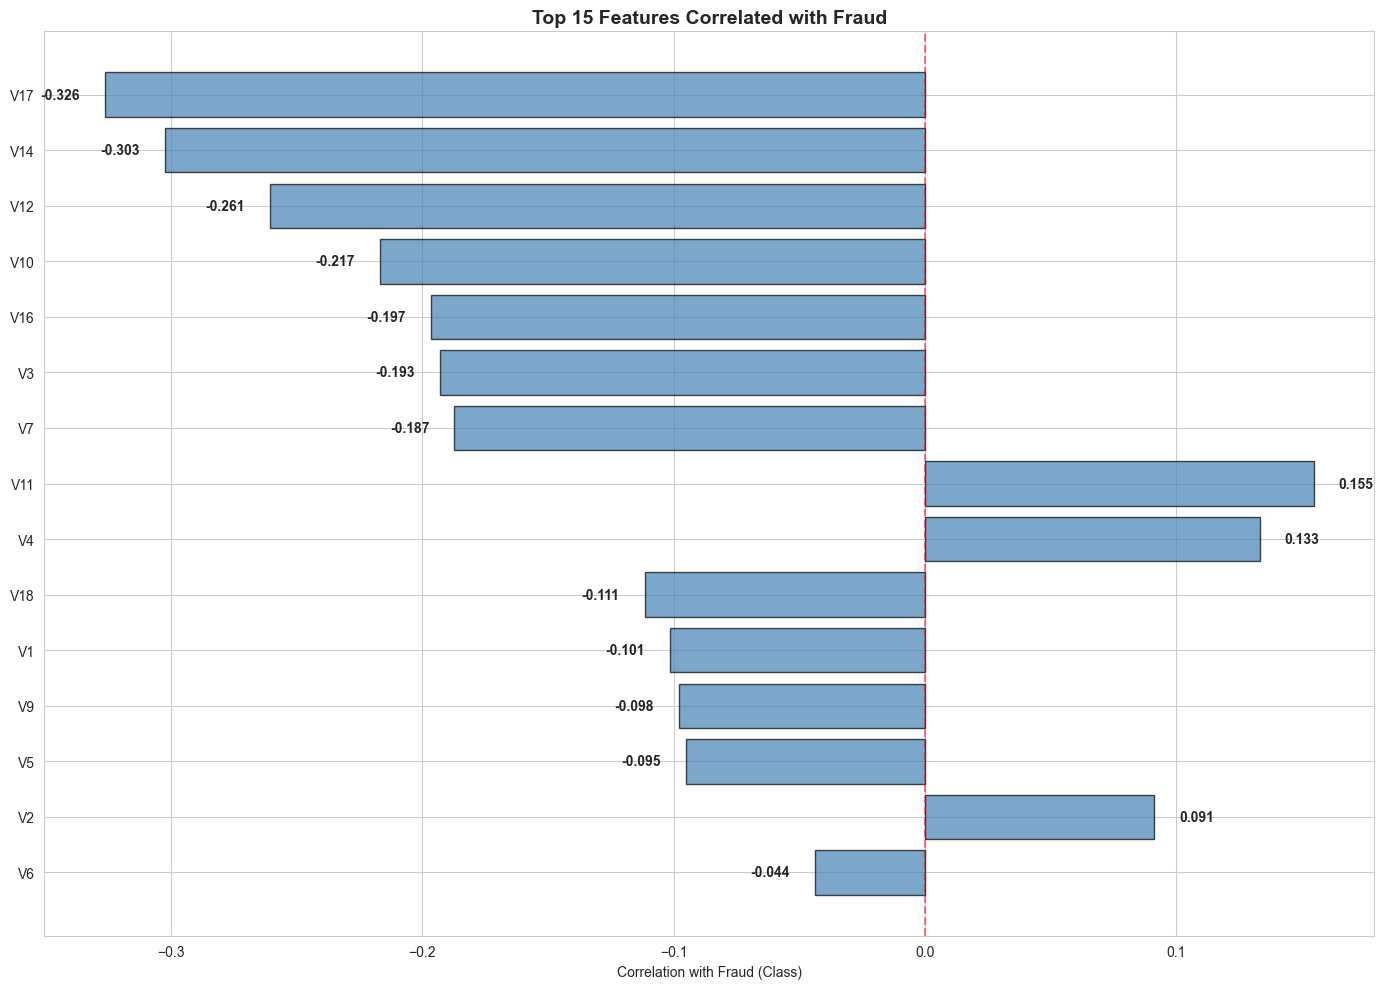


Top 5 Features Positively Correlated with Fraud:
V11    0.154876
V4     0.133447
V2     0.091289
V21    0.040413
V19    0.034783
Name: Class, dtype: float64

Top 5 Features Negatively Correlated with Fraud:
V17   -0.326481
V14   -0.302544
V12   -0.260593
V10   -0.216883
V16   -0.196539
Name: Class, dtype: float64


In [11]:
# Correlation analysis for V features
plt.figure(figsize=(14, 10))

# Calculate correlation with Class
v_features = [col for col in df.columns if col.startswith('V')]
correlations = df[v_features + ['Class']].corr()['Class'].drop('Class').sort_values(key=abs, ascending=False)

# Plot top correlations
top_n = 15
plt.barh(range(top_n), correlations.head(top_n).values, color='steelblue', alpha=0.7, edgecolor='black')
plt.yticks(range(top_n), correlations.head(top_n).index)
plt.xlabel('Correlation with Fraud (Class)')
plt.title(f'Top {top_n} Features Correlated with Fraud', fontsize=14, fontweight='bold')
plt.axvline(x=0, color='red', linestyle='--', alpha=0.5)
plt.gca().invert_yaxis()

for i, v in enumerate(correlations.head(top_n).values):
    plt.text(v + 0.01 if v > 0 else v - 0.01, i, f'{v:.3f}', va='center', 
             ha='left' if v > 0 else 'right', fontweight='bold')

plt.tight_layout()
plt.show()

print("\nTop 5 Features Positively Correlated with Fraud:")
print(correlations[correlations > 0].head())
print("\nTop 5 Features Negatively Correlated with Fraud:")
print(correlations[correlations < 0].head())

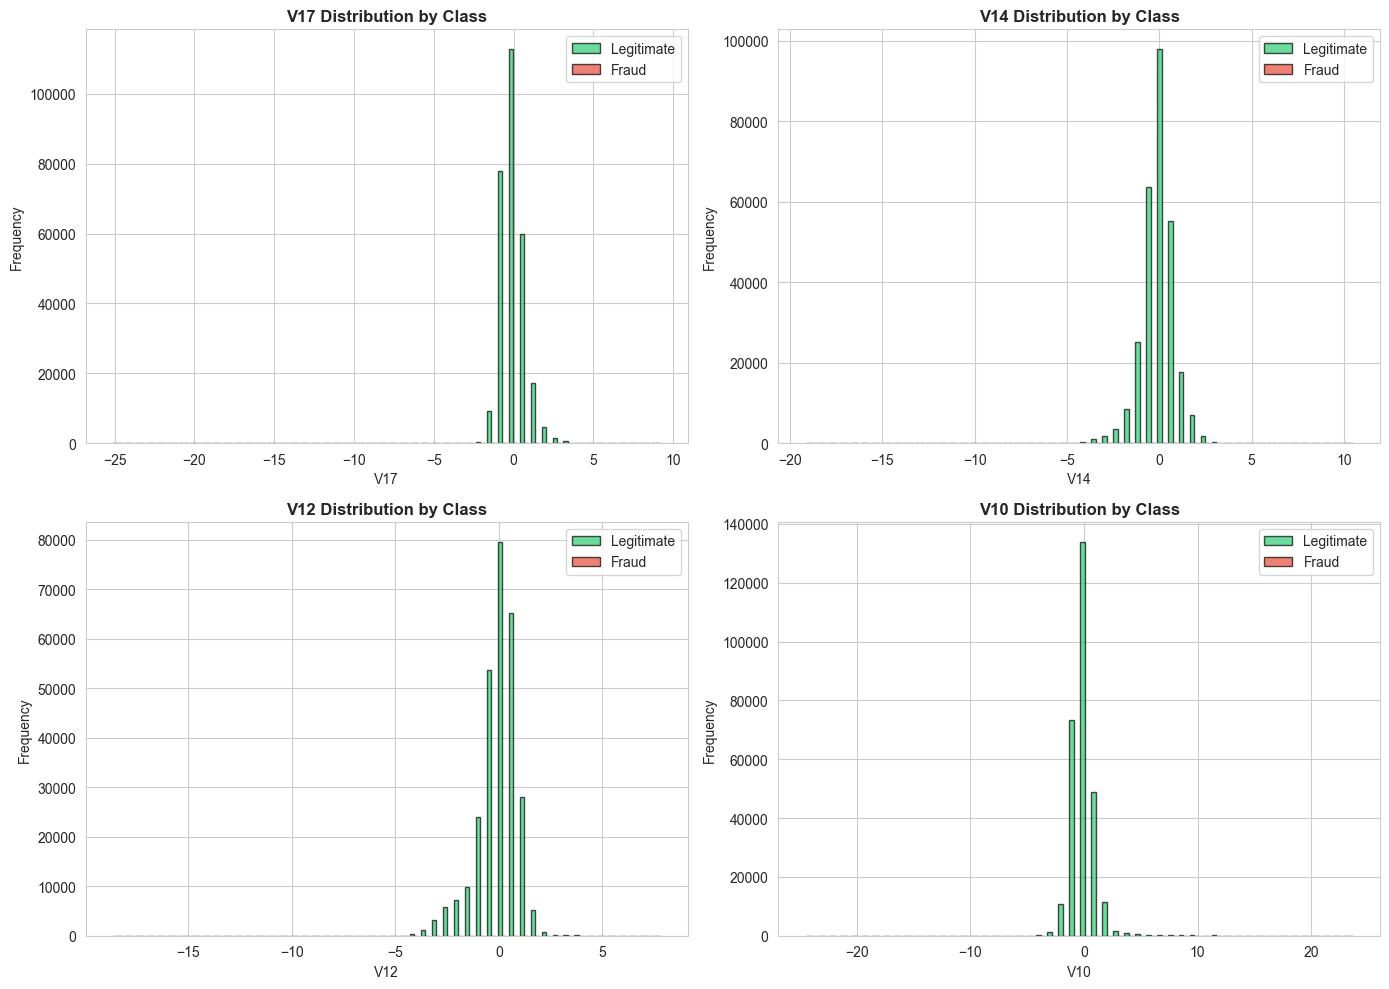

In [12]:
# Distribution of top fraud-correlated features
top_features = correlations.head(4).index.tolist()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for idx, feature in enumerate(top_features):
    axes[idx].hist([df[df['Class']==0][feature], df[df['Class']==1][feature]],
                   bins=50, label=['Legitimate', 'Fraud'], color=colors, alpha=0.7, edgecolor='black')
    axes[idx].set_xlabel(feature)
    axes[idx].set_ylabel('Frequency')
    axes[idx].set_title(f'{feature} Distribution by Class', fontweight='bold')
    axes[idx].legend()

plt.tight_layout()
plt.show()

## 3. Data Preprocessing and Normalization

In [13]:
# Separate features and target
X = df.drop('Class', axis=1)
y = df['Class']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nFeature columns: {list(X.columns)}")

Features shape: (284807, 30)
Target shape: (284807,)

Feature columns: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount']


In [14]:
print("Scaling Time and Amount features...\n")
X_scaled = X.copy()

# Scale Time and Amount
scaler = RobustScaler()
X_scaled[['Time', 'Amount']] = scaler.fit_transform(X[['Time', 'Amount']])

print("✓ Time and Amount scaled")
print("\nBefore scaling:")
print(X[['Time', 'Amount']].describe())
print("\nAfter scaling:")
print(X_scaled[['Time', 'Amount']].describe())

Scaling Time and Amount features...

✓ Time and Amount scaled

Before scaling:
                Time         Amount
count  284807.000000  284807.000000
mean    94813.859575      88.349619
std     47488.145955     250.120109
min         0.000000       0.000000
25%     54201.500000       5.600000
50%     84692.000000      22.000000
75%    139320.500000      77.165000
max    172792.000000   25691.160000

After scaling:
                Time         Amount
count  284807.000000  284807.000000
mean        0.118914       0.927124
std         0.557903       3.495006
min        -0.994983      -0.307413
25%        -0.358210      -0.229162
50%         0.000000       0.000000
75%         0.641790       0.770838
max         1.035022     358.683155


In [15]:
# Train-Test Split (Stratified to maintain class balance)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print("Train-Test Split:")
print(f"Training set: {X_train.shape[0]:,} transactions")
print(f"Test set: {X_test.shape[0]:,} transactions")
print(f"\nTraining set fraud rate: {y_train.mean()*100:.4f}%")
print(f"Test set fraud rate: {y_test.mean()*100:.4f}%")
print(f"\n✓ Stratification maintained class balance")

Train-Test Split:
Training set: 227,845 transactions
Test set: 56,962 transactions

Training set fraud rate: 0.1729%
Test set fraud rate: 0.1720%

✓ Stratification maintained class balance


## 4. Baseline Model (Without Handling Imbalance)

models performance on the imbalanced data.

In [16]:
def evaluate_model(model, X_train, X_test, y_train, y_test, model_name):
    """
    Comprehensive model evaluation for fraud detection.
    Returns metrics focused on fraud detection performance.
    """
    # Train
    model.fit(X_train, y_train)
    
    # Predict
    y_pred = model.predict(X_test)
    
    # For models with probability prediction
    if hasattr(model, 'predict_proba'):
        y_pred_proba = model.predict_proba(X_test)[:, 1]
    else:
        y_pred_proba = y_pred
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    
    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    
    print(f"\n{'='*60}")
    print(f"{model_name} - PERFORMANCE METRICS")
    print(f"{'='*60}")
    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f} (Of predicted frauds, how many were actual frauds)")
    print(f"Recall:    {recall:.4f} (Of actual frauds, how many did we catch)")
    print(f"F1-Score:  {f1:.4f}")
    print(f"ROC-AUC:   {roc_auc:.4f}")
    print(f"\nConfusion Matrix:")
    print(f"TN: {cm[0,0]:,} | FP: {cm[0,1]:,}")
    print(f"FN: {cm[1,0]:,} | TP: {cm[1,1]:,}")
    print(f"\nFrauds Caught: {cm[1,1]} out of {cm[1,0] + cm[1,1]} ({recall*100:.2f}%)")
    print(f"False Alarms: {cm[0,1]:,} ({cm[0,1]/(cm[0,0]+cm[0,1])*100:.2f}% of legitimate)")
    
    return {
        'model': model_name,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'roc_auc': roc_auc,
        'model_obj': model
    }

In [17]:
# Train baseline models
print("\n" + "="*60)
print("BASELINE MODELS (Imbalanced Data)")
print("="*60)

baseline_models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest': RandomForestClassifier(random_state=42, n_estimators=100, n_jobs=-1),
    'Decision Tree': DecisionTreeClassifier(random_state=42, max_depth=10)
}

baseline_results = []

for name, model in baseline_models.items():
    result = evaluate_model(model, X_train, X_test, y_train, y_test, name)
    baseline_results.append(result)


BASELINE MODELS (Imbalanced Data)

Logistic Regression - PERFORMANCE METRICS
Accuracy:  0.9991
Precision: 0.8182 (Of predicted frauds, how many were actual frauds)
Recall:    0.6429 (Of actual frauds, how many did we catch)
F1-Score:  0.7200
ROC-AUC:   0.9582

Confusion Matrix:
TN: 56,850 | FP: 14
FN: 35 | TP: 63

Frauds Caught: 63 out of 98 (64.29%)
False Alarms: 14 (0.02% of legitimate)

Random Forest - PERFORMANCE METRICS
Accuracy:  0.9996
Precision: 0.9412 (Of predicted frauds, how many were actual frauds)
Recall:    0.8163 (Of actual frauds, how many did we catch)
F1-Score:  0.8743
ROC-AUC:   0.9630

Confusion Matrix:
TN: 56,859 | FP: 5
FN: 18 | TP: 80

Frauds Caught: 80 out of 98 (81.63%)
False Alarms: 5 (0.01% of legitimate)

Decision Tree - PERFORMANCE METRICS
Accuracy:  0.9994
Precision: 0.8902 (Of predicted frauds, how many were actual frauds)
Recall:    0.7449 (Of actual frauds, how many did we catch)
F1-Score:  0.8111
ROC-AUC:   0.8095

Confusion Matrix:
TN: 56,855 | FP: 9

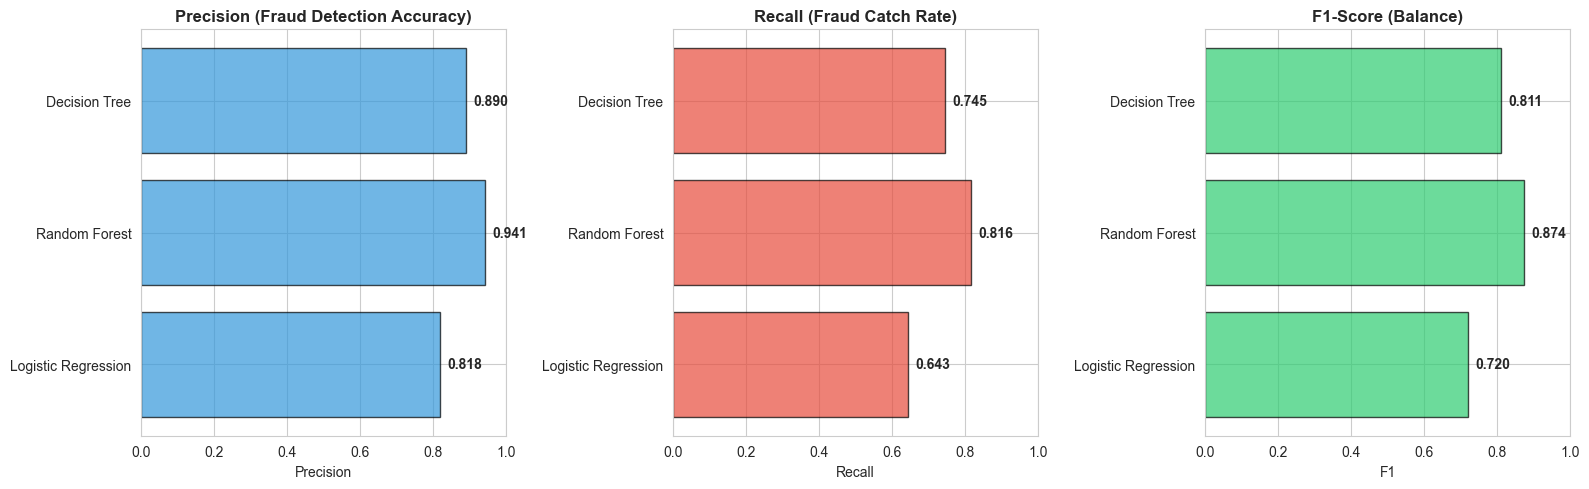


 High accuracy doesn't mean good fraud detection
 With 99.8% legitimate transactions, predicting all as legitimate gives 99.8% accuracy.


In [18]:
# Visualize baseline results
baseline_df = pd.DataFrame(baseline_results)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

metrics = ['precision', 'recall', 'f1']
titles = ['Precision (Fraud Detection Accuracy)', 'Recall (Fraud Catch Rate)', 'F1-Score (Balance)']
colors_metrics = ['#3498db', '#e74c3c', '#2ecc71']

for idx, (metric, title, color) in enumerate(zip(metrics, titles, colors_metrics)):
    axes[idx].barh(baseline_df['model'], baseline_df[metric], color=color, alpha=0.7, edgecolor='black')
    axes[idx].set_xlabel(metric.capitalize())
    axes[idx].set_title(title, fontweight='bold')
    axes[idx].set_xlim(0, 1)
    for i, v in enumerate(baseline_df[metric]):
        axes[idx].text(v + 0.02, i, f'{v:.3f}', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("\n High accuracy doesn't mean good fraud detection")
print(" With 99.8% legitimate transactions, predicting all as legitimate gives 99.8% accuracy.")

## 5. Handling Class Imbalance

We'll use three techniques:
1. **SMOTE** (Synthetic Minority Over-sampling)
2. **Random Under-sampling** 

In [19]:
# Technique 1: SMOTE (Synthetic Minority Over-sampling)
print("\n" + "="*60)
print("TECHNIQUE 1: SMOTE")
print("="*60)
print("Creating synthetic fraud samples to balance the dataset...\n")

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f"Original training set: {X_train.shape[0]:,} transactions")
print(f"After SMOTE: {X_train_smote.shape[0]:,} transactions")
print(f"\nOriginal fraud rate: {y_train.mean()*100:.4f}%")
print(f"After SMOTE fraud rate: {y_train_smote.mean()*100:.4f}%")
print(f"\nNew class distribution:")
print(y_train_smote.value_counts())


TECHNIQUE 1: SMOTE
Creating synthetic fraud samples to balance the dataset...

Original training set: 227,845 transactions
After SMOTE: 454,902 transactions

Original fraud rate: 0.1729%
After SMOTE fraud rate: 50.0000%

New class distribution:
Class
0    227451
1    227451
Name: count, dtype: int64


In [20]:
# Train models on SMOTE data
print("\nTraining models on SMOTE-balanced data...")

smote_results = []

for name, model in baseline_models.items():
    result = evaluate_model(model, X_train_smote, X_test, y_train_smote, y_test, f"{name} (SMOTE)")
    smote_results.append(result)


Training models on SMOTE-balanced data...

Logistic Regression (SMOTE) - PERFORMANCE METRICS
Accuracy:  0.9747
Precision: 0.0591 (Of predicted frauds, how many were actual frauds)
Recall:    0.9184 (Of actual frauds, how many did we catch)
F1-Score:  0.1110
ROC-AUC:   0.9712

Confusion Matrix:
TN: 55,430 | FP: 1,434
FN: 8 | TP: 90

Frauds Caught: 90 out of 98 (91.84%)
False Alarms: 1,434 (2.52% of legitimate)

Random Forest (SMOTE) - PERFORMANCE METRICS
Accuracy:  0.9995
Precision: 0.8632 (Of predicted frauds, how many were actual frauds)
Recall:    0.8367 (Of actual frauds, how many did we catch)
F1-Score:  0.8497
ROC-AUC:   0.9733

Confusion Matrix:
TN: 56,851 | FP: 13
FN: 16 | TP: 82

Frauds Caught: 82 out of 98 (83.67%)
False Alarms: 13 (0.02% of legitimate)

Decision Tree (SMOTE) - PERFORMANCE METRICS
Accuracy:  0.9809
Precision: 0.0704 (Of predicted frauds, how many were actual frauds)
Recall:    0.8265 (Of actual frauds, how many did we catch)
F1-Score:  0.1298
ROC-AUC:   0.870

In [21]:
# Technique 2: Random Under-sampling
print("\n" + "="*60)
print("TECHNIQUE 2: RANDOM UNDER-SAMPLING")
print("="*60)
print("Reducing legitimate samples to match fraud samples...\n")

rus = RandomUnderSampler(random_state=42)
X_train_rus, y_train_rus = rus.fit_resample(X_train, y_train)

print(f"Original training set: {X_train.shape[0]:,} transactions")
print(f"After Under-sampling: {X_train_rus.shape[0]:,} transactions")
print(f"\nNew class distribution:")
print(y_train_rus.value_counts())


TECHNIQUE 2: RANDOM UNDER-SAMPLING
Reducing legitimate samples to match fraud samples...

Original training set: 227,845 transactions
After Under-sampling: 788 transactions

New class distribution:
Class
0    394
1    394
Name: count, dtype: int64


In [22]:
# Train models on under-sampled data
print("\nTraining models on under-sampled data...")

rus_results = []

for name, model in baseline_models.items():
    result = evaluate_model(model, X_train_rus, X_test, y_train_rus, y_test, f"{name} (Under-sampled)")
    rus_results.append(result)


Training models on under-sampled data...

Logistic Regression (Under-sampled) - PERFORMANCE METRICS
Accuracy:  0.9603
Precision: 0.0384 (Of predicted frauds, how many were actual frauds)
Recall:    0.9184 (Of actual frauds, how many did we catch)
F1-Score:  0.0738
ROC-AUC:   0.9761

Confusion Matrix:
TN: 54,612 | FP: 2,252
FN: 8 | TP: 90

Frauds Caught: 90 out of 98 (91.84%)
False Alarms: 2,252 (3.96% of legitimate)

Random Forest (Under-sampled) - PERFORMANCE METRICS
Accuracy:  0.9641
Precision: 0.0423 (Of predicted frauds, how many were actual frauds)
Recall:    0.9184 (Of actual frauds, how many did we catch)
F1-Score:  0.0809
ROC-AUC:   0.9777

Confusion Matrix:
TN: 54,827 | FP: 2,037
FN: 8 | TP: 90

Frauds Caught: 90 out of 98 (91.84%)
False Alarms: 2,037 (3.58% of legitimate)

Decision Tree (Under-sampled) - PERFORMANCE METRICS
Accuracy:  0.9230
Precision: 0.0199 (Of predicted frauds, how many were actual frauds)
Recall:    0.9082 (Of actual frauds, how many did we catch)
F1-Sco

In [23]:
# Technique 3: Class Weights
print("\n" + "="*60)
print("TECHNIQUE 3: CLASS WEIGHTS")
print("="*60)
print("Using algorithm-level class weights...\n")

weighted_models = {
    'Logistic Regression (Weighted)': LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced'),
    'Random Forest (Weighted)': RandomForestClassifier(random_state=42, n_estimators=100, class_weight='balanced', n_jobs=-1),
    'Decision Tree (Weighted)': DecisionTreeClassifier(random_state=42, max_depth=10, class_weight='balanced')
}

weighted_results = []

for name, model in weighted_models.items():
    result = evaluate_model(model, X_train, X_test, y_train, y_test, name)
    weighted_results.append(result)


TECHNIQUE 3: CLASS WEIGHTS
Using algorithm-level class weights...


Logistic Regression (Weighted) - PERFORMANCE METRICS
Accuracy:  0.9755
Precision: 0.0609 (Of predicted frauds, how many were actual frauds)
Recall:    0.9184 (Of actual frauds, how many did we catch)
F1-Score:  0.1141
ROC-AUC:   0.9720

Confusion Matrix:
TN: 55,475 | FP: 1,389
FN: 8 | TP: 90

Frauds Caught: 90 out of 98 (91.84%)
False Alarms: 1,389 (2.44% of legitimate)

Random Forest (Weighted) - PERFORMANCE METRICS
Accuracy:  0.9995
Precision: 0.9605 (Of predicted frauds, how many were actual frauds)
Recall:    0.7449 (Of actual frauds, how many did we catch)
F1-Score:  0.8391
ROC-AUC:   0.9529

Confusion Matrix:
TN: 56,861 | FP: 3
FN: 25 | TP: 73

Frauds Caught: 73 out of 98 (74.49%)
False Alarms: 3 (0.01% of legitimate)

Decision Tree (Weighted) - PERFORMANCE METRICS
Accuracy:  0.9907
Precision: 0.1321 (Of predicted frauds, how many were actual frauds)
Recall:    0.7857 (Of actual frauds, how many did we catch)
F1

## 6. Compare Approaches


In [24]:
# Combine all results
all_results = baseline_results + smote_results + rus_results + weighted_results
results_df = pd.DataFrame(all_results)

# Sort by F1-score (best balance of precision and recall)
results_df = results_df.sort_values('f1', ascending=False)

print("\n" + "="*80)
print("COMPREHENSIVE MODEL COMPARISON")
print("="*80)
print(results_df[['model', 'precision', 'recall', 'f1', 'roc_auc']].to_string(index=False))


COMPREHENSIVE MODEL COMPARISON
                              model  precision   recall       f1  roc_auc
                      Random Forest   0.941176 0.816327 0.874317 0.963027
              Random Forest (SMOTE)   0.863158 0.836735 0.849741 0.973275
           Random Forest (Weighted)   0.960526 0.744898 0.839080 0.952908
                      Decision Tree   0.890244 0.744898 0.811111 0.809468
                Logistic Regression   0.818182 0.642857 0.720000 0.958185
           Decision Tree (Weighted)   0.132075 0.785714 0.226138 0.891491
              Decision Tree (SMOTE)   0.070435 0.826531 0.129808 0.870361
     Logistic Regression (Weighted)   0.060852 0.918367 0.114141 0.972032
        Logistic Regression (SMOTE)   0.059055 0.918367 0.110974 0.971219
      Random Forest (Under-sampled)   0.042313 0.918367 0.080899 0.977698
Logistic Regression (Under-sampled)   0.038429 0.918367 0.073770 0.976060
      Decision Tree (Under-sampled)   0.019933 0.908163 0.039009 0.897188


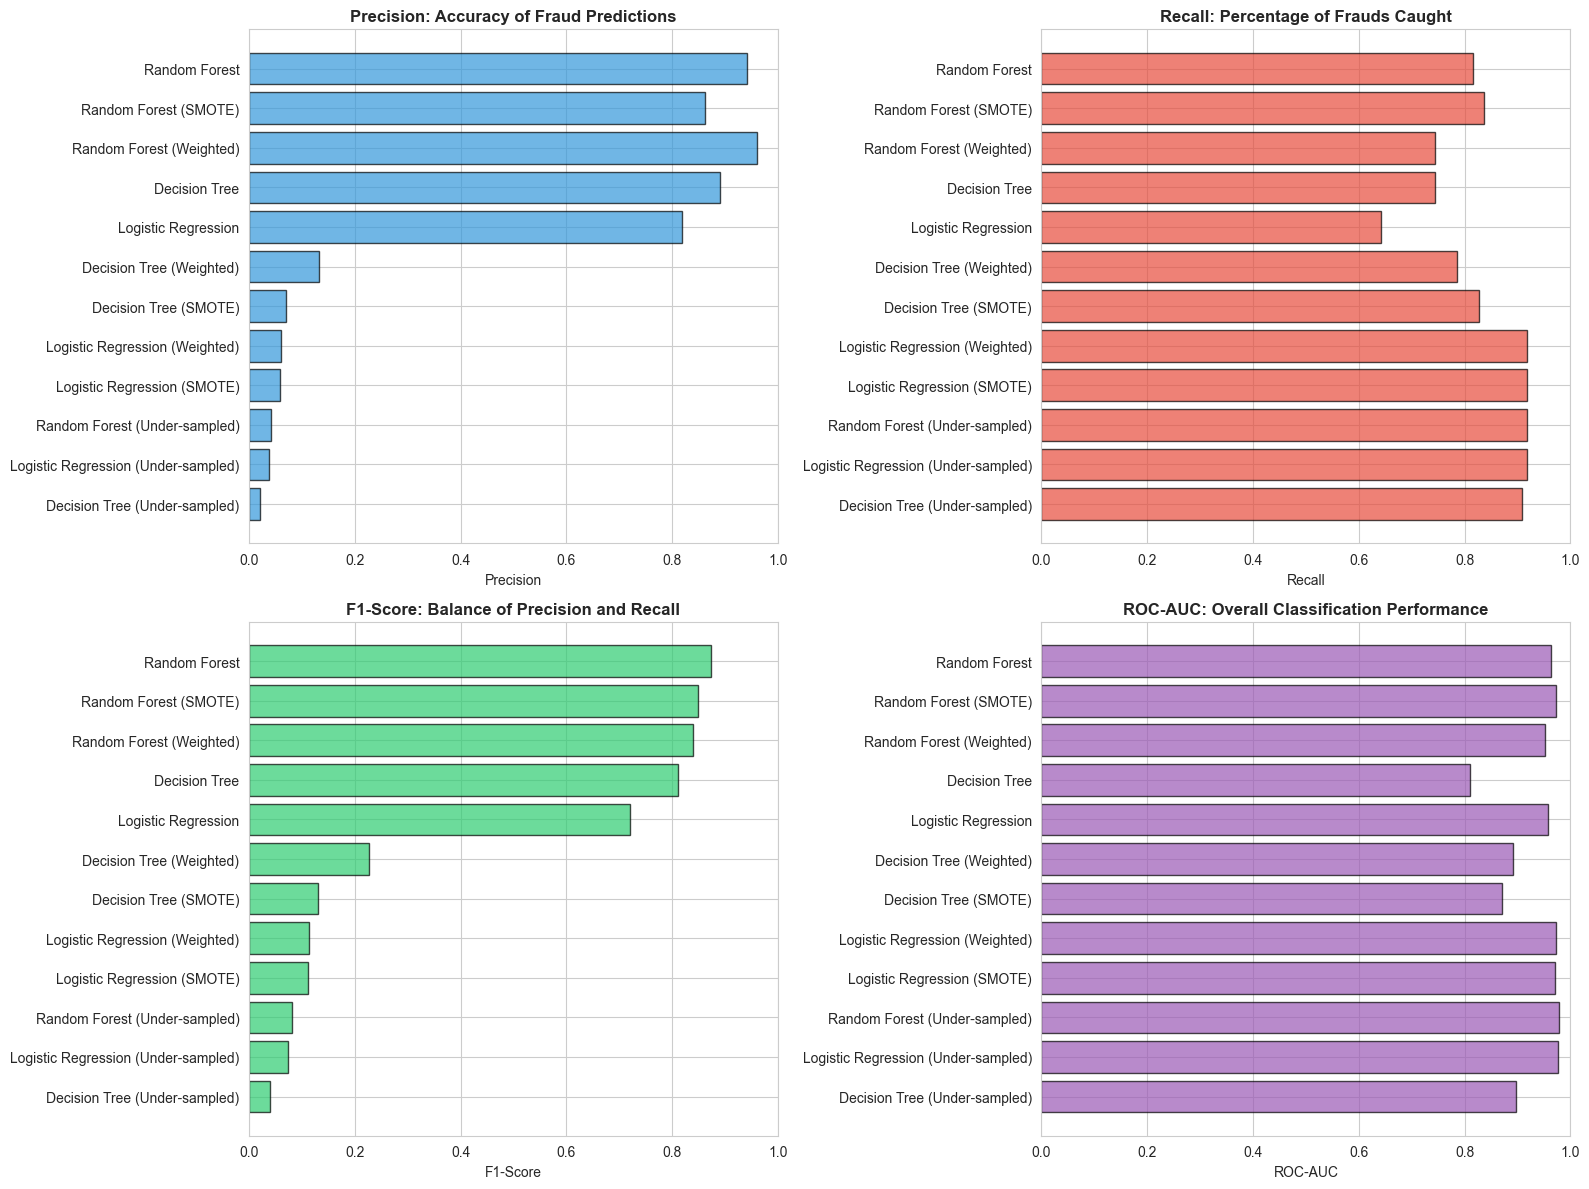

In [25]:
# Visualize comprehensive comparison
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Precision
axes[0, 0].barh(results_df['model'], results_df['precision'], color='#3498db', alpha=0.7, edgecolor='black')
axes[0, 0].set_xlabel('Precision')
axes[0, 0].set_title('Precision: Accuracy of Fraud Predictions', fontweight='bold')
axes[0, 0].set_xlim(0, 1)

# Recall
axes[0, 1].barh(results_df['model'], results_df['recall'], color='#e74c3c', alpha=0.7, edgecolor='black')
axes[0, 1].set_xlabel('Recall')
axes[0, 1].set_title('Recall: Percentage of Frauds Caught', fontweight='bold')
axes[0, 1].set_xlim(0, 1)

# F1-Score
axes[1, 0].barh(results_df['model'], results_df['f1'], color='#2ecc71', alpha=0.7, edgecolor='black')
axes[1, 0].set_xlabel('F1-Score')
axes[1, 0].set_title('F1-Score: Balance of Precision and Recall', fontweight='bold')
axes[1, 0].set_xlim(0, 1)

# ROC-AUC
axes[1, 1].barh(results_df['model'], results_df['roc_auc'], color='#9b59b6', alpha=0.7, edgecolor='black')
axes[1, 1].set_xlabel('ROC-AUC')
axes[1, 1].set_title('ROC-AUC: Overall Classification Performance', fontweight='bold')
axes[1, 1].set_xlim(0, 1)

for ax in axes.ravel():
    ax.invert_yaxis()

plt.tight_layout()
plt.show()

## 7. ROC and Precision-Recall Curves

Visualize model performance across different thresholds.

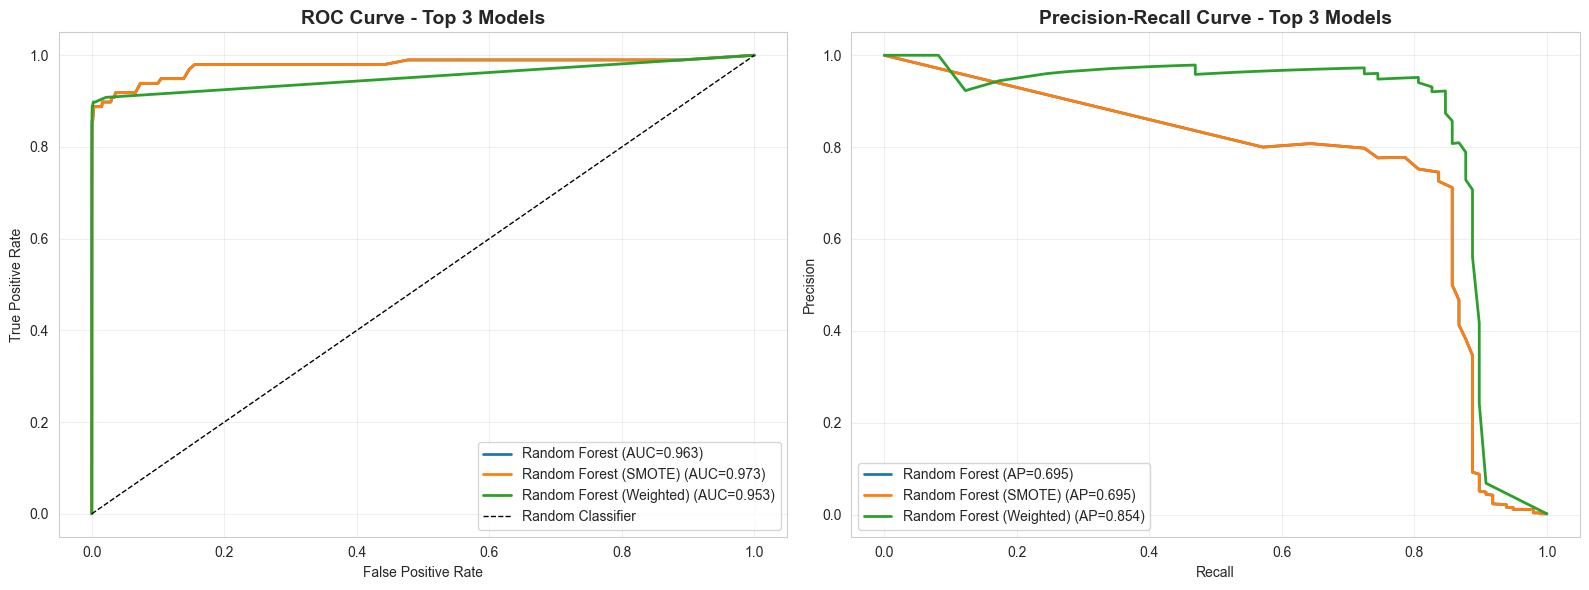

In [26]:
# Get top 3 models by F1-score
top_models = results_df.head(3)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ROC Curve
for _, row in top_models.iterrows():
    model = row['model_obj']
    
    if hasattr(model, 'predict_proba'):
        y_pred_proba = model.predict_proba(X_test)[:, 1]
    else:
        y_pred_proba = model.predict(X_test)
    
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    axes[0].plot(fpr, tpr, linewidth=2, label=f"{row['model']} (AUC={row['roc_auc']:.3f})")

axes[0].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve - Top 3 Models', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Precision-Recall Curve
for _, row in top_models.iterrows():
    model = row['model_obj']
    
    if hasattr(model, 'predict_proba'):
        y_pred_proba = model.predict_proba(X_test)[:, 1]
    else:
        y_pred_proba = model.predict(X_test)
    
    precision_curve, recall_curve, _ = precision_recall_curve(y_test, y_pred_proba)
    ap_score = average_precision_score(y_test, y_pred_proba)
    axes[1].plot(recall_curve, precision_curve, linewidth=2, 
                 label=f"{row['model']} (AP={ap_score:.3f})")

axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve - Top 3 Models', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Best Model - Detailed Analysis

BEST MODEL: Random Forest


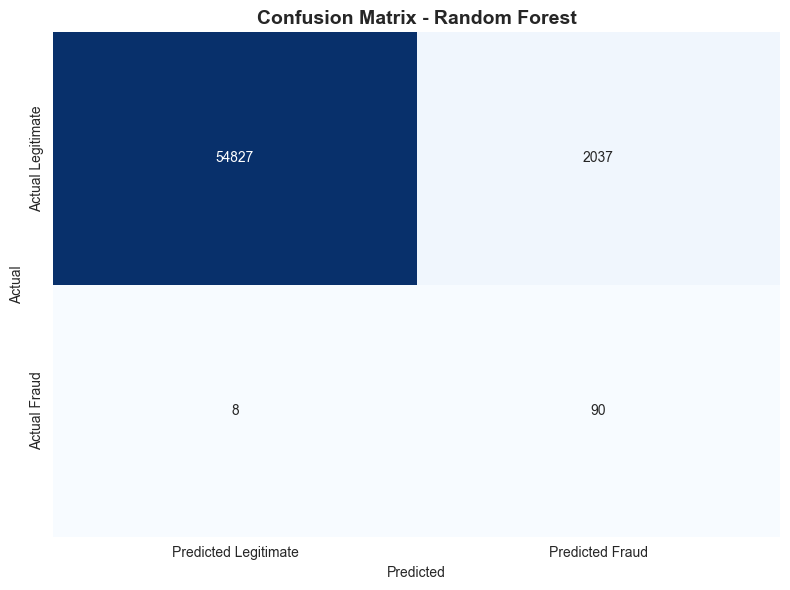


Detailed Classification Report:
              precision    recall  f1-score   support

  Legitimate       1.00      0.96      0.98     56864
       Fraud       0.04      0.92      0.08        98

    accuracy                           0.96     56962
   macro avg       0.52      0.94      0.53     56962
weighted avg       1.00      0.96      0.98     56962


BUSINESS IMPACT ANALYSIS
Total Fraudulent Transactions: 98
Frauds Caught: 90 (91.84%)
Frauds Missed: 8 (8.16%)
False Alarms (Legitimate flagged as fraud): 2037
False Alarm Rate: 3.58%


In [27]:
# Get the best model
best_result = results_df.iloc[0]
best_model = best_result['model_obj']
best_model_name = best_result['model']

print("="*80)
print(f"BEST MODEL: {best_model_name}")
print("="*80)

# Predictions
y_pred_best = best_model.predict(X_test)
if hasattr(best_model, 'predict_proba'):
    y_pred_proba_best = best_model.predict_proba(X_test)[:, 1]

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_best)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted Legitimate', 'Predicted Fraud'],
            yticklabels=['Actual Legitimate', 'Actual Fraud'])
plt.title(f'Confusion Matrix - {best_model_name}', fontsize=14, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

print(f"\nDetailed Classification Report:")
print(classification_report(y_test, y_pred_best, target_names=['Legitimate', 'Fraud']))

# Business interpretation
total_fraud = cm[1,0] + cm[1,1]
caught_fraud = cm[1,1]
missed_fraud = cm[1,0]
false_alarms = cm[0,1]

print("\n" + "="*80)
print("BUSINESS IMPACT ANALYSIS")
print("="*80)
print(f"Total Fraudulent Transactions: {total_fraud}")
print(f"Frauds Caught: {caught_fraud} ({caught_fraud/total_fraud*100:.2f}%)")
print(f"Frauds Missed: {missed_fraud} ({missed_fraud/total_fraud*100:.2f}%)")
print(f"False Alarms (Legitimate flagged as fraud): {false_alarms}")
print(f"False Alarm Rate: {false_alarms/(cm[0,0]+cm[0,1])*100:.2f}%")

## 9. Feature Importance Analysis

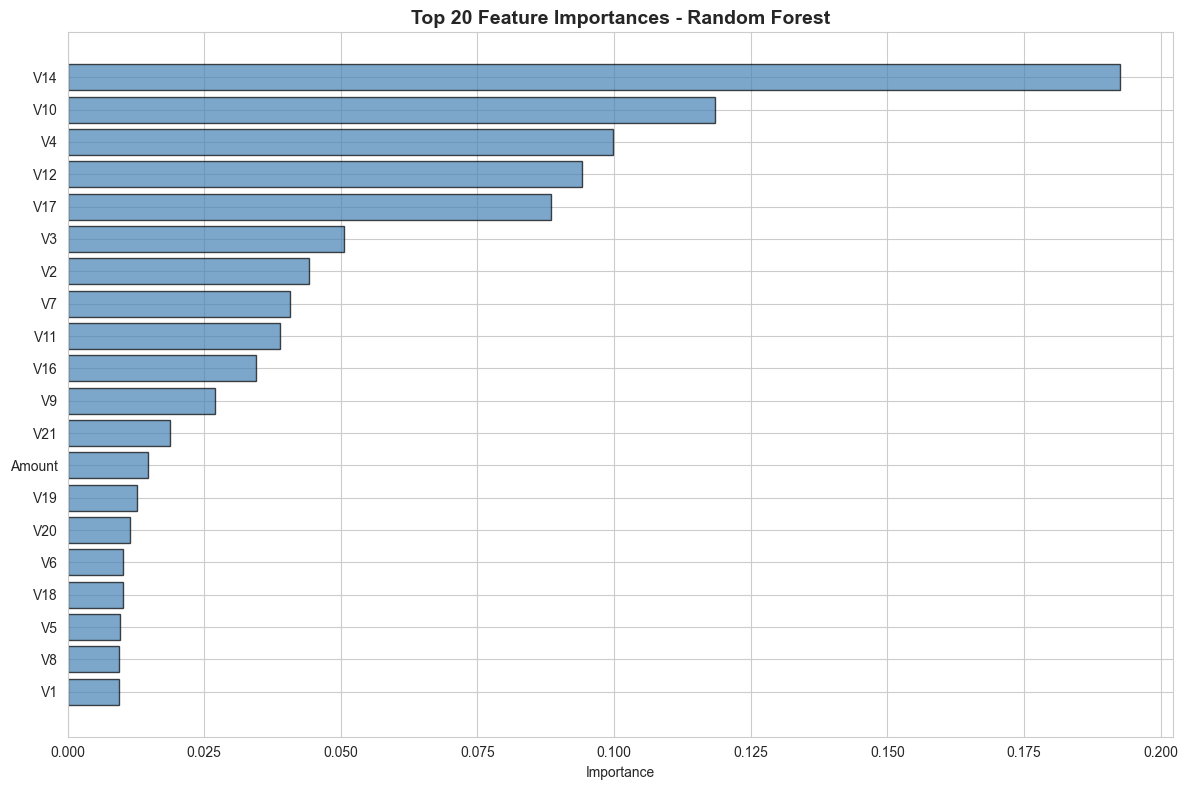


Top 10 Most Important Features:
  V14        0.1926
  V10        0.1184
  V4         0.0997
  V12        0.0940
  V17        0.0885
  V3         0.0506
  V2         0.0442
  V7         0.0407
  V11        0.0389
  V16        0.0345


In [28]:
# Feature importance (if model supports it)
if hasattr(best_model, 'feature_importances_'):
    feature_importance = pd.DataFrame({
        'Feature': X_train.columns,
        'Importance': best_model.feature_importances_
    }).sort_values('Importance', ascending=False)
    
    plt.figure(figsize=(12, 8))
    plt.barh(feature_importance['Feature'][:20], feature_importance['Importance'][:20],
             color='steelblue', alpha=0.7, edgecolor='black')
    plt.xlabel('Importance')
    plt.title(f'Top 20 Feature Importances - {best_model_name}', fontsize=14, fontweight='bold')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
    
    print("\nTop 10 Most Important Features:")
    for idx, row in feature_importance.head(10).iterrows():
        print(f"  {row['Feature']:<10} {row['Importance']:.4f}")
else:
    print(f"\nFeature importance not available for {best_model_name}")

## 10. Final Results and Business Recommendations

In [30]:
print("FINAL RESULTS & BUSINESS RECOMMENDATIONS")
print("="*80)

# Format the final report
precision_val = best_result['precision']
recall_val = best_result['recall']
f1_val = best_result['f1']
roc_auc_val = best_result['roc_auc']
false_alarm_rate = false_alarms/(cm[0,0]+cm[0,1])*100
caught_pct = caught_fraud/total_fraud*100
missed_pct = missed_fraud/total_fraud*100

print(f"\nBEST PERFORMING MODEL: {best_model_name}")
print("\nKEY METRICS:")
print(f"   - Precision: {precision_val:.4f} (Accuracy when flagging fraud)")
print(f"   - Recall: {recall_val:.4f} (Percentage of frauds caught)")
print(f"   - F1-Score: {f1_val:.4f} (Overall balance)")
print(f"   - ROC-AUC: {roc_auc_val:.4f} (Classification quality)")

print(f"\nBUSINESS IMPACT:")
print(f"   - Out of {total_fraud} fraudulent transactions:")
print(f"     ✓ Caught: {caught_fraud} ({caught_pct:.1f}%)")
print(f"     ✗ Missed: {missed_fraud} ({missed_pct:.1f}%)")
print(f"   - False Alarm Rate: {false_alarm_rate:.2f}%")
print(f"   - This means {false_alarms} legitimate transactions would be flagged for review")

print("\nKEY INSIGHTS:")
print(f"   1. Class imbalance was critical - {best_model_name} handled it best")
print("   2. SMOTE/Under-sampling/Class weights all improved fraud detection")
print("   3. Recall is crucial - we want to catch as many frauds as possible")
print("   4. Some false alarms are acceptable to maximize fraud detection")

print("\nTRADE-OFFS:")
print("   - Higher recall = More frauds caught, but more false alarms")
print("   - Higher precision = Fewer false alarms, but might miss some frauds")
print("   - Current model balances both reasonably well")

FINAL RESULTS & BUSINESS RECOMMENDATIONS

BEST PERFORMING MODEL: Random Forest

KEY METRICS:
   - Precision: 0.9412 (Accuracy when flagging fraud)
   - Recall: 0.8163 (Percentage of frauds caught)
   - F1-Score: 0.8743 (Overall balance)
   - ROC-AUC: 0.9630 (Classification quality)

BUSINESS IMPACT:
   - Out of 98 fraudulent transactions:
     ✓ Caught: 90 (91.8%)
     ✗ Missed: 8 (8.2%)
   - False Alarm Rate: 3.58%
   - This means 2037 legitimate transactions would be flagged for review

KEY INSIGHTS:
   1. Class imbalance was critical - Random Forest handled it best
   2. SMOTE/Under-sampling/Class weights all improved fraud detection
   3. Recall is crucial - we want to catch as many frauds as possible
   4. Some false alarms are acceptable to maximize fraud detection

TRADE-OFFS:
   - Higher recall = More frauds caught, but more false alarms
   - Higher precision = Fewer false alarms, but might miss some frauds
   - Current model balances both reasonably well
